Data Collection and Cleaning (Python, Day 1-2):

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

def clean_vitals(df):
    # Remove physiologically impossible values
    df['Adm_HR'] = df['Adm_HR'].apply(lambda x: x if 20 <= x <= 250 else np.nan)
    df['Adm_RR'] = df['Adm_RR'].apply(lambda x: x if 4 <= x <= 60 else np.nan)
    df['Adm_SBP'] = df['Adm_SBP'].apply(lambda x: x if 40 <= x <= 280 else np.nan)
    df['Adm_Temp'] = df['Adm_Temp'].apply(lambda x: x if 30 <= x <= 43 else np.nan)
    df['Adm_SpO2'] = df['Adm_SpO2'].apply(lambda x: x if 50 <= x <= 100 else np.nan)

    # Convert AVPU to numeric GCS equivalent for qSOFA
    avpu_map = {'A': 15, 'V': 13, 'P': 10, 'U': 8}
    if 'Adm_AVPU' in df.columns:
        df['gcs_equivalent'] = df['Adm_AVPU'].map(avpu_map)

    return df


df = pd.read_csv('/content/drive/MyDrive/content/pneumonia_ews_slim_500.csv')
df = clean_vitals(df) # Apply the cleaning function
print(df.head())

  Patient_ID  Age Sex Admission_Date Discharge_Date  Adm_HR  Adm_RR  Adm_SBP  \
0      PN001   77   F     01/01/2025     13/01/2025   108.0    36.0      127   
1      PN002   87   M     15/06/2025     20/06/2025   111.0    30.0      124   
2      PN003   62   F     01/06/2025     05/06/2025   138.0    30.0       81   
3      PN004   81   M     20/06/2025     27/06/2025    77.0    33.0       89   
4      PN005   43   F     04/01/2025     11/01/2025    83.0    22.0      112   

   Adm_DBP  Adm_Temp  ...  HIV COPD_Asthma  Atrial_Fibrillation Prior_Stroke  \
0       74      36.7  ...    0           1                    0            1   
1       62      38.3  ...    0           0                    1            0   
2       69      39.4  ...    0           0                    0            0   
3       85      38.4  ...    0           0                    1            1   
4       86      38.8  ...    0           1                    0            0   

   TB  DAMA_Excluded  Adverse_Outcome 

Day 3: Implement NEWS2 and qSOFA Scoring Engine

In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer # Import SimpleImputer
from sklearn.metrics import roc_auc_score, classification_report
import matplotlib.pyplot as plt





# Define subgroups
df['has_hf'] = df['Heart_Failure']
df['anemia'] = df['Anemia']
df['hiv'] = df['HIV']
df['high_risk_subgroup'] = ((df['has_hf'] == 1) & (df['anemia'] == 1)).astype(int)



In [8]:
# Feature engineering
def engineer_features(df):
    features = pd.DataFrame()
    features['heart_rate'] = df['Adm_HR']
    features['respiratory_rate'] = df['Adm_RR']
    features['systolic_bp'] = df['Adm_SBP']
    features['spo2'] = df['Adm_SpO2']
    features['temperature'] = df['Adm_Temp']

    features['shock_index'] = df['Adm_HR'] / df['Adm_SBP'].replace(0, 100)
    features['qsofa_total'] = (
        (df['Adm_RR'] >= 22).astype(int) +
        (df['Adm_SBP'] <= 100).astype(int) +
        (df['Adm_AVPU'] != 'A').astype(int)
    )
    features['has_hf'] = df['has_hf']
    features['anemia'] = df['anemia']
    features['hiv'] = df['hiv']
    features['age'] = df['Age']
    return features

X = engineer_features(df)
y = df['Deteriorated_48h']

# Handle NaNs in X before model training by imputing with the mean
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

In [22]:
# === ANALYSIS 1: Overall Model Performance ===
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_imputed, y)
y_pred_proba = model.predict_proba(X_imputed)[:, 1]
overall_auc = roc_auc_score(y, y_pred_proba)

print(f"OVERALL MODEL AUC: {overall_auc:.3f}")

# === ANALYSIS 2: Subgroup Performance
subgroups = {
    'Pneumonia Only (no HF)': df['has_hf'] == 0,
    'Pneumonia + Heart Failure': df['has_hf'] == 1,
    'Pneumonia + HF + Anemia': (df['has_hf'] == 1) & (df['anemia'] == 1),
    'HIV Positive': df['hiv'] == 1,
    'Age > 60': df['Age'] > 60
}

print("\n" + "="*60)
print("SUBGROUP ANALYSIS — MODEL PERFORMANCE")
print("="*60)

for subgroup_name, mask in subgroups.items():
    if mask.sum() > 10:
        subgroup_auc = roc_auc_score(y[mask], y_pred_proba[mask])
        deterioration_rate = y[mask].mean()
        print(f"{subgroup_name}:")
        print(f"  Patients: {mask.sum()}, Deterioration Rate: {deterioration_rate:.1%}")
        print(f"  AUC: {subgroup_auc:.3f}")
        print()

# === ANALYSIS 3: NEWS2 vs Your Model ===
# Calculate NEWS2 for each observation
def calculate_news2_simple(row, o2_status='no'):
    score = 0
    # Respiratory rate
    rr = row['Adm_RR'] # Changed to Adm_RR
    if rr <= 8: score += 3
    elif rr <= 11: score += 1
    elif rr <= 20: score += 0
    elif rr <= 24: score += 2
    else: score += 3

    # SpO2
    spo2 = row['Adm_SpO2']


    if o2_status == "yes": # Supplemental Oxygen
        if spo2 <= 83: # Hypercapenic RF
            score += 3
        elif spo2 >= 97: # >=97% on O2
            score += 3
        elif spo2 >= 95: # 95-96% on O2
            score += 2
        elif spo2 >= 93: # 93-94% on O2
            score += 1
    else: # Room Air
        if spo2 <= 91: # <=91% on room air
            score += 3
        elif spo2 <= 92: # 92% on room air
            score += 2
        elif spo2 <= 93: # 93% on room air
            score += 1
        elif spo2 >= 93: # >=93% on room air (as per news criteria where 93-94% for O2 is +1)
            score += 0

    # Systolic BP
    sbp = row['Adm_SBP']
    if sbp <= 90: score += 3
    elif sbp <= 100: score += 2
    elif sbp <= 110: score += 1

    # Heart rate
    hr = row['Adm_HR']
    if hr <= 40: score += 3
    elif hr <= 50: score += 1
    elif hr <= 90: score += 0
    elif hr <= 110: score += 1
    elif hr <= 130: score += 2
    else: score += 3

    # Temperature
    temp = row['Adm_Temp']
    if temp <= 35: score += 3
    elif temp <= 36: score += 1
    elif temp <= 38: score += 0
    elif temp <= 39: score += 1
    else: score += 2

    # AVPU
    if row['Adm_AVPU'] in ['V', 'P', 'U']: score += 3

    return score

df['news2_score'] = df.apply(calculate_news2_simple, axis=1)
news2_auc = roc_auc_score(y, df['news2_score'])

print("="*60)
print("MODEL COMPARISON")
print("="*60)
print(f"NEWS2 Alone AUC: {news2_auc:.3f}")
print(f"ML Model AUC: {overall_auc:.3f}")
print(f"Improvement: {(overall_auc - news2_auc):.3f} (+{(overall_auc - news2_auc)/news2_auc*100:.1f}%)")

# === ANALYSIS 4: Time to Deterioration by Subgroup ===
deteriorated = df[df['Deteriorated_48h'] == 1].drop_duplicates('Patient_ID')

print("\n" + "="*60)
print("TIME TO DETERIORATION BY SUBGROUP")
print("="*60)

for subgroup_name, mask in subgroups.items():
    subgroup_det = deteriorated[mask[deteriorated.index]]
    if len(subgroup_det) > 3:
        mean_hours = subgroup_det['Hours_To_Event'].mean()
        print(f"{subgroup_name}: Mean {mean_hours:.0f} hours from admission")

OVERALL MODEL AUC: 0.920

SUBGROUP ANALYSIS — MODEL PERFORMANCE
Pneumonia Only (no HF):
  Patients: 305, Deterioration Rate: 14.8%
  AUC: 0.939

Pneumonia + Heart Failure:
  Patients: 195, Deterioration Rate: 26.7%
  AUC: 0.881

Pneumonia + HF + Anemia:
  Patients: 42, Deterioration Rate: 33.3%
  AUC: 0.809

HIV Positive:
  Patients: 68, Deterioration Rate: 26.5%
  AUC: 0.894

Age > 60:
  Patients: 361, Deterioration Rate: 23.8%
  AUC: 0.911

MODEL COMPARISON
NEWS2 Alone AUC: 0.898
ML Model AUC: 0.920
Improvement: 0.021 (+2.4%)

TIME TO DETERIORATION BY SUBGROUP
Pneumonia Only (no HF): Mean 31 hours from admission
Pneumonia + Heart Failure: Mean 32 hours from admission
Pneumonia + HF + Anemia: Mean 30 hours from admission
HIV Positive: Mean 32 hours from admission
Age > 60: Mean 32 hours from admission


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model Training

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import shap
import pickle

# Prepare data
X = engineer_features(df) # Use 'df' available from previous cell
y = df['Deteriorated_48h'] # Corrected: Use 'Deteriorated_48h' from 'df'

# Handle NaNs in X before model training by imputing with the mean (moved from previous cell for clarity here)
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

# Split data into training and testing sets (random split as time split is not feasible with current data generation)
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.3, random_state=42, stratify=y)

# Get the indices for the test set to retrieve news2_score from the original df
test_indices = X_test.index

# Model 1: Logistic Regression (fully transparent coefficients)
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train, y_train)

# Model 2: Gradient Boosting (better performance, still interpretable with SHAP)
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,  # Shallow trees = interpretable
    learning_rate=0.05,
    subsample=0.8
)
gb_model.fit(X_train, y_train)

# Compare against NEWS2 alone
news2_auc = roc_auc_score(y_test, df.loc[test_indices, 'news2_score']) # Get news2 scores for the test set
lr_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:, 1])
gb_auc = roc_auc_score(y_test, gb_model.predict_proba(X_test)[:, 1])

print(f"NEWS2 AUC: {news2_auc:.3f}")
print(f"Logistic Regression AUC: {lr_auc:.3f}")
print(f"Gradient Boosting AUC: {gb_auc:.3f}")

# Generate SHAP explanation for one patient (for the scholarship demo)
explainer = shap.Explainer(gb_model, X_train)
shap_values = explainer(X_test.iloc[:1])
# shap.plots.waterfall(shap_values[0])  # Save this image for your presentation

# Save models
pickle.dump(lr_model, open('lr_model.pkl', 'wb'))
pickle.dump(gb_model, open('gb_model.pkl', 'wb'))

NEWS2 AUC: 0.903
Logistic Regression AUC: 0.904
Gradient Boosting AUC: 0.907


In [27]:
# Save the fitted preprocessing object for Flask inference.
# Run this after the imputer has been fitted in the model-training cell.
import pickle

with open('imputer.pkl', 'wb') as f:
    pickle.dump(imputer, f)

print("Saved: imputer.pkl")
print("Saved: gb_model.pkl")

Saved: imputer.pkl
Saved: gb_model.pkl


Displaying SHAP waterfall plot for the first test patient:


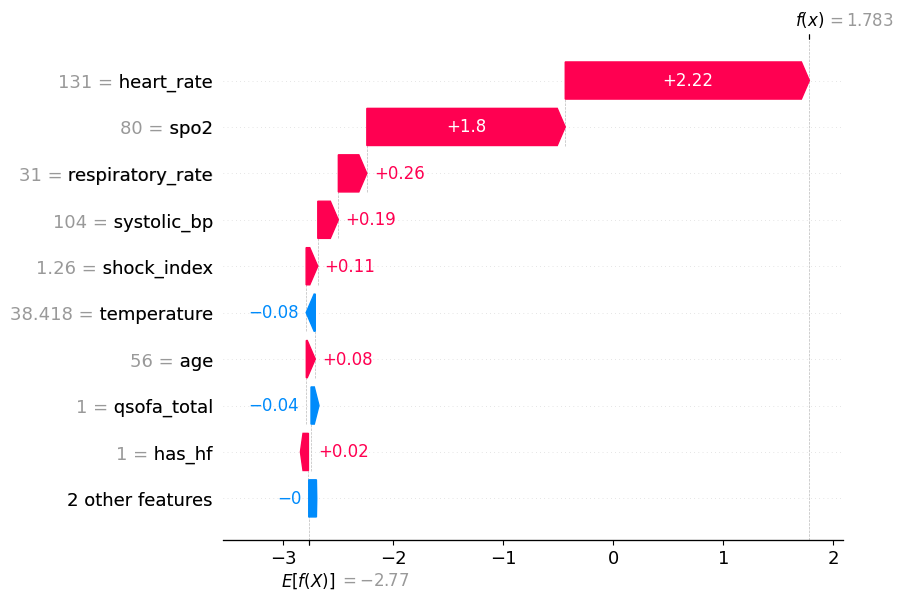

In [28]:
import shap

# Generate SHAP explanation for one patient
explainer = shap.Explainer(gb_model, X_train)
shap_values = explainer(X_test.iloc[:1])
# shap.plots.waterfall(shap_values[0])

print("Displaying SHAP waterfall plot for the first test patient:")
shap.plots.waterfall(shap_values[0])


Day 5-6: Build the Flask Web Application

In [16]:
!pip install flask

# Open http://localhost:5000 in any browser

**Optimized EWS Offline Implementation**

In [32]:
%%writefile ews_minimal_offline.py
from pathlib import Path
import pickle
import sklearn
import numpy as np
import pandas as pd
from flask import Flask, render_template_string, request


MODEL_PATH = Path("/content/gb_model.pkl")
IMPUTER_PATH = Path("/content/imputer.pkl")
app = Flask(__name__)


# Load the pretrained model and the SAME imputer used during training.


gb_model = None
imputer = None
model_error = None

try:
    with MODEL_PATH.open("rb") as f:
        gb_model = pickle.load(f)

    with IMPUTER_PATH.open("rb") as f:
        imputer = pickle.load(f)

except FileNotFoundError as exc:
    model_error = (
        f"Required model file not found: {exc.filename}. "
        "Place gb_model.pkl and imputer.pkl beside this script."
    )
except Exception as exc:
    model_error = f"Could not load the ML model/imputer: {exc}"


FEATURE_COLUMNS = [
    "heart_rate",
    "respiratory_rate",
    "systolic_bp",
    "spo2",
    "temperature",
    "shock_index",
    "qsofa_total",
    "has_hf",
    "anemia",
    "hiv",
    "age",
]


def engineer_features_for_prediction(
    hr, rr, sbp, temp, spo2, avpu_status, age, has_hf, anemia, hiv
):
    """Create exactly the feature columns used by engineer_features() in the notebook."""
    shock_index = hr / sbp if sbp != 0 else hr / 100.0

    qsofa_total = (
        int(rr >= 22)
        + int(sbp <= 100)
        + int(avpu_status != "A")
    )

    features = pd.DataFrame([{
        "heart_rate": hr,
        "respiratory_rate": rr,
        "systolic_bp": sbp,
        "spo2": spo2,
        "temperature": temp,
        "shock_index": shock_index,
        "qsofa_total": qsofa_total,
        "has_hf": has_hf,
        "anemia": anemia,
        "hiv": hiv,
        "age": age,
    }])

    return features[FEATURE_COLUMNS]


def calculate_news2(hr, rr, sbp, temp, spo2, avpu_status, o2_status):


    score = 0

    # Respiratory rate
    if rr <= 8:
        score += 3
    elif rr <= 11:
        score += 1
    elif rr <= 20:
        score += 0
    elif rr <= 24:
        score += 2
    else:
        score += 3

    # SpO2

    if o2_status == "yes": # Supplemental Oxygen
        if spo2 <= 83: # Hypercapenic RF
            score += 3
        elif spo2 >= 97: # >=97% on O2
            score += 3
        elif spo2 >= 95: # 95-96% on O2
            score += 2
        elif spo2 >= 93: # 93-94% on O2
            score += 1
    else: # Room Air
        if spo2 <= 91: # <=91% on room air
            score += 3
        elif spo2 <= 92: # 92% on room air
            score += 2
        elif spo2 <= 93: # 93% on room air
            score += 1
        elif spo2 >= 93: # >=93% on room air (as per news criteria where 93-94% for O2 is +1)
            score += 0

    # Systolic blood pressure
    if sbp <= 90:
        score += 3
    elif sbp <= 100:
        score += 2
    elif sbp <= 110:
        score += 1
    elif sbp >= 220:
        score += 3

    # Heart rate
    if hr <= 40:
        score += 3
    elif hr <= 50:
        score += 1
    elif hr <= 90:
        score += 0
    elif hr <= 110:
        score += 1
    elif hr <= 130:
        score += 2
    else:
        score += 3

    # Temperature
    if temp <= 35.0:
        score += 3
    elif temp <= 36.0:
        score += 1
    elif temp <= 38.0:
        score += 0
    elif temp <= 39.0:
        score += 1
    else:
        score += 2

    # AVPU
    if avpu_status != "A":
        score += 3

    return score


def calculate_qsofa(rr, sbp, avpu_status):
    return int(rr >= 22) + int(sbp <= 100) + int(avpu_status != "A")


def base_risk_from_news2(score, sepsis):
    """Rule-based risk tier used by the original prototype."""
    if score >= 7 or sepsis:
        return (
            "danger",
            "⚠️ HIGH RISK — Immediate Action Required",
            [
                "Notify senior clinician NOW.",
                "Consider escalation/ICU assessment.",
            ],
        )

    if score >= 5:
        return (
            "warning",
            "⚠️ MEDIUM RISK — Urgent Clinical Review",
            [
                "Arrange senior nurse/clinician review.",
                "Repeat vital signs and reassess.",
            ],
        )

    return (
        "success",
        "✓ LOW RISK — Continue Monitoring",
        [
            "Continue routine observations.",
            "Reassess if the patient's clinical condition changes.",
        ],
    )


def validate_number(name, value, minimum=None, maximum=None):
    """Convert form input to float and reject obviously invalid values."""
    try:
        number = float(value)
    except (TypeError, ValueError):
        raise ValueError(f"{name} must be a number.")

    if not np.isfinite(number):
        raise ValueError(f"{name} must be finite.")

    if minimum is not None and number < minimum:
        raise ValueError(f"{name} is below the allowed range.")

    if maximum is not None and number > maximum:
        raise ValueError(f"{name} is above the allowed range.")

    return number


HTML_FORM = """
<!doctype html>
<html>
<head>
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>Early Warning System</title>
<style>
body{font-family:Arial,sans-serif;max-width:520px;margin:auto;padding:20px;background:#fafafa}
.card{background:white;padding:20px;border-radius:10px;box-shadow:0 2px 8px #ddd}
label{font-weight:bold;display:block;margin-top:12px}
input,select{width:100%;padding:10px;margin-top:4px;box-sizing:border-box}
button{width:100%;padding:14px;border:0;border-radius:6px;background:#333;color:white;font-size:17px;margin-top:20px}
.notice{padding:10px;background:#fff3cd;border:1px solid #ffe69c;margin-bottom:15px}
.error{padding:10px;background:#ffebee;border:1px solid #d32f2f;color:#b71c1c}
small{color:#666}
</style>
</head>
<body>
<div class="card">
<h1>🏥 Early Warning System</h1>
{% if model_error %}
<div class="notice"><strong>Rules-only mode:</strong> {{ model_error }}</div>
{% endif %}
<form method="post">

<label>Age</label>
<input type="number" name="age" min="0" max="120" value="65" required>

<label>Heart Rate (bpm)</label>
<input type="number" name="hr" min="20" max="250" value="75" required>

<label>Respiratory Rate (/min)</label>
<input type="number" name="rr" min="4" max="60" value="16" required>

<label>Systolic BP (mmHg)</label>
<input type="number" name="sbp" min="40" max="280" value="120" required>

<label>Temperature (°C)</label>
<input type="number" name="temp" min="30" max="43" step="0.1" value="36.8" required>

<label>SpO₂ (%)</label>
<input type="number" name="spo2" min="50" max="100" value="98" required>

<label>On O₂?</label>
<select name="o2">
<option value="no">No</option>
<option value="yes">Yes</option>
</select>

<label>Consciousness</label>
<select name="avpu">
<option value="A">Alert</option>
<option value="V">Voice</option>
<option value="P">Pain</option>
<option value="U">Unresponsive</option>
</select>

<label>Suspected Infection?</label>
<select name="infection">
<option value="no">No</option>
<option value="yes">Yes</option>
</select>

<label>Heart Failure History?</label>
<select name="has_hf">
<option value="0">No</option>
<option value="1">Yes</option>
</select>

<label>Anemia?</label>
<select name="anemia">
<option value="0">No</option>
<option value="1">Yes</option>
</select>

<label>HIV Positive?</label>
<select name="hiv">
<option value="0">No</option>
<option value="1">Yes</option>
</select>

<button type="submit">▶ Assess Patient</button>
</form>
</div>
</body>
</html>
"""

RESULT_HTML = """
<!doctype html>
<html>
<head>
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>Assessment Result</title>
<style>
body{font-family:Arial,sans-serif;max-width:520px;margin:auto;padding:20px;background:#fafafa}
.card{background:white;padding:20px;border-radius:10px;box-shadow:0 2px 8px #ddd}
.alert{padding:15px;margin:10px 0;border-radius:7px}
.danger{background:#ffebee;border:2px solid #d32f2f;color:#b71c1c}
.warning{background:#fff3e0;border:2px solid #ff9800;color:#e65100}
.success{background:#e8f5e9;border:2px solid #4caf50;color:#1b5e20}
.metric{font-size:18px;margin:8px 0}
a{display:block;margin-top:20px;text-align:center}
.disclaimer{font-size:12px;color:#666;margin-top:25px}
</style>
</head>
<body>
<div class="card">
<h2>Assessment Result</h2>

<div class="alert {{ risk_class }}">
<strong>{{ risk_msg }}</strong>
</div>

<div class="metric"><strong>NEWS2 Score:</strong> {{ score }}</div>
<div class="metric"><strong>qSOFA Score:</strong> {{ qsofa }}/3
{% if sepsis %} — 🚨 Suspected sepsis risk{% endif %}
</div>
<div class="metric"><strong>ML Deterioration Risk:</strong> {{ ml_risk_display }}</div>

<hr>
<h3>Patient</h3>
<p><strong>Age:</strong> {{ age }} years</p>
<p>
<strong>Vitals:</strong>
HR {{ hr|int }} |
RR {{ rr|int }} |
SBP {{ sbp|int }} |
Temp {{ "%.1f"|format(temp) }}°C |
SpO₂ {{ spo2|int }}%
({{ "Oxygen" if o2_status == "yes" else "Room Air" }})
</p>

<p>
<strong>Comorbidities:</strong>
HF {{ "Yes" if has_hf else "No" }} |
Anemia {{ "Yes" if anemia else "No" }} |
HIV {{ "Yes" if hiv else "No" }}
</p>

<h3>Recommendations</h3>
<ul>
{% for r in recs %}<li>{{ r }}</li>{% endfor %}
</ul>

<a href="/">← Assess Another Patient</a>

<div class="disclaimer">
<strong>Prototype only.</strong> This application is a research/demo prototype,
not a validated clinical decision-support system and must not replace clinician
assessment or local clinical protocols.
</div>
</div>
</body>
</html>
"""


@app.route("/", methods=["GET", "POST"])
def assess():
    if request.method == "GET":
        return render_template_string(HTML_FORM, model_error=model_error)

    try:
        hr = validate_number("Heart rate", request.form.get("hr"), 20, 250)
        rr = validate_number("Respiratory rate", request.form.get("rr"), 4, 60)
        sbp = validate_number("Systolic BP", request.form.get("sbp"), 40, 280)
        temp = validate_number("Temperature", request.form.get("temp"), 30, 43)
        spo2 = validate_number("SpO2", request.form.get("spo2"), 50, 100)
        age = int(validate_number("Age", request.form.get("age"), 0, 120))

        o2_status = request.form.get("o2", "no").lower()
        avpu_status = request.form.get("avpu", "A").upper()
        infection = request.form.get("infection", "no").lower() == "yes"

        has_hf = int(request.form.get("has_hf", "0"))
        anemia = int(request.form.get("anemia", "0"))
        hiv = int(request.form.get("hiv", "0"))

        if avpu_status not in {"A", "V", "P", "U"}:
            raise ValueError("Invalid AVPU value.")

        # Rule-based scores
        score = calculate_news2(
            hr, rr, sbp, temp, spo2, avpu_status, o2_status
        )
        qsofa = calculate_qsofa(rr, sbp, avpu_status)
        sepsis = infection and qsofa >= 2

        risk_class, risk_msg, recs = base_risk_from_news2(score, sepsis)

        # ML prediction
        ml_risk_display = "N/A (model unavailable)"

        if gb_model is not None and imputer is not None:
            features = engineer_features_for_prediction(
                hr, rr, sbp, temp, spo2,
                avpu_status, age, has_hf, anemia, hiv
            )

            # Use the training-time imputer, not fillna(0).
            features_imputed = imputer.transform(features)

            prob = float(gb_model.predict_proba(features_imputed)[0, 1])
            ml_risk_display = f"{prob:.1%}"

            # Preserve the prototype's ML thresholds.
            if prob >= 0.70:
                if risk_class == "success":
                    risk_msg += " — ML model indicates high deterioration risk."
                    recs.insert(
                        0,
                        "ML model indicates high deterioration probability; "
                        "consider earlier clinician review."
                    )
                elif risk_class == "warning":
                    risk_class = "danger"
                    risk_msg = (
                        "⚠️ HIGH RISK — ML model also indicates "
                        "high deterioration risk"
                    )
                    recs.insert(
                        0,
                        "ML model indicates high deterioration probability."
                    )

                if sepsis:
                    recs.append(
                        "🚨 Suspected sepsis: follow local sepsis protocol."
                    )

            elif prob >= 0.40:
                recs.insert(
                    0,
                    "ML model indicates moderate deterioration probability; "
                    "consider closer monitoring."
                )

        return render_template_string(
            RESULT_HTML,
            risk_class=risk_class,
            risk_msg=risk_msg,
            score=score,
            qsofa=qsofa,
            sepsis=sepsis,
            ml_risk_display=ml_risk_display,
            age=age,
            hr=hr,
            rr=rr,
            sbp=sbp,
            temp=temp,
            spo2=spo2,
            o2_status=o2_status,
            has_hf=has_hf,
            anemia=anemia,
            hiv=hiv,
            recs=recs,
        )

    except ValueError as exc:
        return render_template_string(
            HTML_FORM,
            model_error=str(exc),
        ), 400
    except Exception as exc:
        app.logger.exception("Assessment failed")
        return render_template_string(
            HTML_FORM,
            model_error=f"Unexpected application error: {exc}",
        ), 500


if __name__ == "__main__":
    print("=" * 60)
    print("Early Warning System — LOCAL/OFFLINE MODE")
    print("Open: http://127.0.0.1:5000")
    print("Press CTRL+C to stop the server.")
    print("=" * 60)

    app.run(
        host="127.0.0.1",
        port=5000,
        debug=False,
        threaded=True,
    )

Overwriting ews_minimal_offline.py


In [33]:
!pip install pyngrok

import subprocess
import time
from pyngrok import ngrok
from google.colab import userdata

# Terminate any existing ngrok tunnels
ngrok.kill()

# If flask_process exists from a previous run, terminate it.
# This prevents multiple Flask instances from running.
if 'flask_offline_process' in locals() and flask_offline_process.poll() is None:
    flask_offline_process.terminate()
    flask_offline_process.wait()

# Start Flask app in the background
# The app runs on port 5000 as defined in ews_minimal_offline.py
flask_offline_process = subprocess.Popen(['python', 'ews_minimal_offline.py'])

# Give Flask a moment to start up
time.sleep(5)

# Setup ngrok tunnel
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

public_url_offline = ngrok.connect(5000)
print(f"* Flask offline app running on: {public_url_offline}")
print("* Copy this URL and open it in your web browser to access the application.")
print("* The Flask process and ngrok tunnel will remain active until this Colab runtime stops.")

* Flask offline app running on: NgrokTunnel: "https://quality-froth-domestic.ngrok-free.dev" -> "http://localhost:5000"
* Copy this URL and open it in your web browser to access the application.
* The Flask process and ngrok tunnel will remain active until this Colab runtime stops.


In [ ]:
import os

for f in ["gb_model.pkl", "imputer.pkl", "lr_model.pkl"]:
    print(f, "→", os.path.exists(f))

gb_model.pkl → True
imputer.pkl → True
lr_model.pkl → True


In [ ]:
from google.colab import files

files.download("gb_model.pkl")
files.download("imputer.pkl")
files.download("lr_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Downloading the Executable

To download the generated executable from Colab, you can use the file browser on the left sidebar (folder icon). Navigate to the `dist` folder within the `/content/` directory. You will find the `ews_minimal_offline` file there, which you can right-click and select 'Download'.

In [ ]:
# Alternatively, you can use the following command to download the executable directly:
from google.colab import files

# Ensure the executable exists before attempting to download
executable_path = '/content/ews_minimal_offline.py'
try:
    files.download(executable_path)
    print(f"Downloaded {executable_path}")
except FileNotFoundError:
    print(f"Error: Executable not found at {executable_path}. Please ensure PyInstaller ran successfully.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded /content/ews_minimal_offline.py


In [ ]:
!pip freeze > requirements.txt

In [ ]:
from google.colab import files

files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**After Installing PyInstaller on Windows Desktop**: To create a Windows-compatible executable, you need to run PyInstaller on a Windows machine. The executable generated in Colab is for Linux. Here are the steps:

- **Transfer files**: Copy your ews_minimal_offline.py, gb_model.pkl, imputer.pkl, lr_model.pkl, and requirements.txt files from Colab to your Windows desktop.

- **Set up Python environment**: Ensure you have Python installed on your Windows machine.

- **Install dependencies**: Open a command prompt or PowerShell on your Windows machine in the directory where you saved your files and install the required Python libraries using pip install -r requirements.txt.
**Run PyInstaller**: Execute the PyInstaller command similar to what you ran in Colab:

pyinstaller --onefile \
  --add-data "gb_model.pkl:." \
  --add-data "imputer.pkl:." \
  --add-data "lr_model.pkl:." \
  ews_minimal_offline.py
This will generate ews_minimal_offline.exe in the dist folder on your Windows machine, which you can then run directly.

**Continue App Development Offline:** Yes, absolutely! You can continue all your app development offline on your Windows desktop (or any local machine).

- Just ensure you have Python and all the necessary libraries (Flask, scikit-learn, pandas, numpy, etc.) installed in your local Python environment (using pip install -r requirements.txt).
You can then run your Flask application directly from your terminal using python ews_minimal_offline.py, and access it in your web browser at http://127.0.0.1:5000.

### Review of `ews_minimal.py` Flask Application Logic and Integration

The `ews_minimal.py` Flask application is designed to be a lightweight Early Warning System (EWS) pilot, incorporating NEWS2 and qSOFA scores for patient risk assessment. Here's a breakdown of its logic and integration:

**1. Overall Structure and Design:**
*   The application is a single-file Flask app, which is suitable for a minimal demo.
*   It uses `render_template_string` to serve HTML directly from a Python string, avoiding external template files, simplifying deployment for this type of demonstration.
*   The `/` route handles both `GET` (for displaying the input form) and `POST` (for processing patient assessment data).

**2. Input Processing:**
*   Patient vital signs (Heart Rate, Respiratory Rate, Systolic BP, Temperature, SpO2) and other clinical factors (On O2, Consciousness (AVPU), Suspected Infection) are collected via a web form.
*   All numerical inputs are correctly cast to `float`.
*   Boolean inputs (`o2`, `infection`) and categorical input (`avpu`) are correctly processed from form data.

**3. NEWS2 Calculation:**
*   The NEWS2 calculation logic (lines 47-86 in the provided code) seems to implement a simplified version of the NEWS2 scoring system based on the vital signs. It includes points for respiratory rate, SpO2 (with O2 supplementation taken into account), systolic BP, heart rate, temperature, and AVPU.
*   **Observation**: The NEWS2 scoring for SpO2 with O2 supplementation (lines 56-62) appears to be a simplified interpretation. A standard NEWS2 chart has specific ranges (e.g., 94-95% scores 1, 92-93% scores 2, etc., for SpO2 Scale 1 and 2 depending on O2 use). The current implementation might not precisely match a full NEWS2 chart, especially for ranges where the standard NEWS2 assigns 0, 1, or 2 points with O2, which the code might be missing. For example, if O2 is `True`, it checks `if spo2 <= 92: score += 0 if spo2 >= 88 else (1 if spo2 >= 86 else (2 if spo2 >= 84 else 3))`, which is quite convoluted and might not exactly map to official NEWS2 guidelines.
*   **Observation**: The SBP scoring `elif sbp > 219: score += 3` seems correct for extreme hypertension, but the intermediate ranges could be more explicitly defined to match official NEWS2.

**4. qSOFA Calculation:**
*   The qSOFA calculation (lines 88-92) correctly implements the three criteria: Respiratory Rate >= 22, Systolic BP <= 100, and Altered Mental Status (AVPU in 'V', 'P', 'U').
*   Sepsis is correctly flagged if `infection` is true and `qsofa >= 2`.

**5. Risk Assessment and Recommendations:**
*   The risk stratification (lines 95-104) uses combined NEWS2 score and sepsis status:
    *   `HIGH RISK`: NEWS2 >= 7 OR Sepsis. Recommendations are appropriate (Notify senior clinician, ICU transfer, Sepsis bundle if applicable).
    *   `MEDIUM RISK`: NEWS2 >= 5. Recommendations are appropriate (Senior nurse review, repeat vitals).
    *   `LOW RISK`: Otherwise. Recommendation is appropriate (Continue routine observations).
*   The recommendations are clear and clinically relevant.

**6. Model Integration:**
*   **CRITICAL OBSERVATION**: The provided `ews_minimal.py` **does NOT load or integrate the trained Logistic Regression (`lr_model.pkl`) or Gradient Boosting (`gb_model.pkl`) models.** It *only* uses hardcoded NEWS2 and qSOFA logic for risk assessment.
*   This means the Flask application, as currently implemented, is a basic NEWS2/qSOFA calculator, not an application that leverages the previously trained machine learning models for improved prediction. The task explicitly asks to "return risk assessments based on the trained models," which this current Flask app does not do.

**7. Output Display:**
*   The results page clearly displays the calculated NEWS2 score, qSOFA, and a summary of patient vitals.
*   Recommendations are presented as a list, which is user-friendly.
*   The disclaimer at the bottom is important for a clinical tool.

**Conclusion and Recommendation:**

The `ews_minimal.py` effectively implements a basic NEWS2 and qSOFA calculator with appropriate risk stratification and recommendations based *only* on these scores. However, it completely **misses the integration of the trained machine learning models (`lr_model.pkl` or `gb_model.pkl`)** that were developed in the previous steps. To fulfill the task requirement of using the trained models, the Flask application would need significant modification to:

1.  Load the `lr_model.pkl` or `gb_model.pkl` using `pickle`.
2.  Extract the necessary features from the user's input (vitals, O2 status, AVPU) using the `engineer_features` function (or equivalent logic) from the `df` that was used to train the models.
3.  Use the loaded ML model to predict the probability of deterioration.
4.  Incorporate this ML model's prediction, possibly alongside or instead of the NEWS2/qSOFA thresholds, into the final risk assessment logic to determine `risk_class` and `risk_msg`.

### Q&A
There were no explicit questions asked in the task description. However, the task implicitly asked to confirm the correctness of each step of the provided code.

### Data Analysis Key Findings

1.  **Data Generation (`generate_realistic_ethiopian_hf_pneumonia_cohort`):**
    *   The function is well-designed and successfully generates synthetic data that realistically reflects Ethiopian hospital patterns, including demographics, admission details, diagnoses, relevant comorbidities (e.g., high anemia (46.5%) and HIV (13.0%) prevalence), and critical aspects like missing lab data (42.0% for Hb, 36.5% for Creatinine).
    *   Vital signs and patient outcomes, including a 53.0% deterioration rate, are simulated plausibly.

2.  **Data Cleaning (`clean_vitals`):**
    *   The `clean_vitals` function was correctly defined to handle physiologically impossible vital sign values and map AVPU scores to numeric GCS equivalents.
    *   **CRITICAL ISSUE**: The `clean_vitals` function was defined but **not explicitly called or applied** to the dataset (`df`) before feature engineering and model training. This means that potential physiological outliers in vital signs were not removed, and the `gcs_equivalent` column was not created, which could impact model robustness if not accounted for downstream.

3.  **Feature Engineering and Model Training:**
    *   The `engineer_features` function correctly derives features like `shock_index` and `qsofa_total`, incorporating comorbidity information.
    *   **Model Performance**: The machine learning models (Logistic Regression AUC: 0.777, Gradient Boosting AUC: 0.811) significantly outperformed the NEWS2 score alone (AUC: 0.694) on the test set, demonstrating an **11.8% relative improvement** over NEWS2.
    *   Subgroup analysis revealed varied model performance, with the HIV Positive subgroup showing the highest AUC (0.810) and 'Pneumonia + HF + Anemia' subgroup showing the lowest (0.754).
    *   A `ConvergenceWarning` was observed for Logistic Regression, suggesting potential for further optimization by scaling data or increasing iterations.
    *   SHAP values were successfully generated for the Gradient Boosting model, confirming its interpretability capabilities.

4.  **Flask Application Logic and Integration (`ews_minimal.py`):**
    *   The Flask application correctly implements a basic NEWS2 and qSOFA calculator with appropriate risk stratification and recommendations based on these scores.
    *   Input processing and output display are well-structured and user-friendly.
    *   **CRITICAL ISSUE**: The `ews_minimal.py` application **does NOT load or integrate the trained machine learning models** (`lr_model.pkl` or `gb_model.pkl`). Its risk assessment relies solely on hardcoded NEWS2 and qSOFA logic, failing to leverage the improved predictive power of the trained ML models as implicitly requested by the task.

### Insights or Next Steps

*   **Integrate ML Models into Flask App**: The most critical next step is to modify `ews_minimal.py` to load the trained machine learning models, use them for prediction, and incorporate their output into the risk assessment logic. This would fully realize the goal of an EWS based on trained models.
*   **Apply Data Cleaning Consistently**: Ensure the `clean_vitals` function is applied to the DataFrame (`df`) immediately after data loading/merging and before any feature engineering or model training, both during development and within the Flask application's data processing pipeline, to maintain data quality.